# Proyek Analisis Data: Analisis Kualitas Jawaban AI

## Menentukan Pertanyaan Bisnis

**Pilar 1: Analisis Keadilan & Standarisasi Penilaian HRD (Standardization)**
- **Pertanyaan 1:** Berapa rata-rata skor akhir kandidat pada masing-masing label kualitas (Weak, Average, Strong) lintas rumpun pekerjaan (Role Family) untuk memastikan tidak adanya bias terhadap rumpun pekerjaan tertentu?

- **Pertanyaan 2:** Berapa persentase kandidat yang mengalami ketimpangan penilaian—di mana mereka dinilai memiliki pemahaman teknis yang tinggi (skor >75)namun mendapatkan penilaian kejelasan komunikasi lisan yang rendah (skor <60)—pada keseluruhan sampel wawancara?


**Pilar 2: Anatomi Jawaban Sukses & Pola Struktur Metrik (Diagnostic)**
- **Pertanyaan 3:** Di antara berbagai komponen kelengkapan respons yang diberikan kandidat (seperti penjelasan konteks, tindakan nyata, ataupun penyertaan bukti angka hasil kerja), elemen mana yang paling menentukan keberhasilan kandidat untuk mencapai kategori kualitas tertinggi ('Strong')?

- **Pertanyaan 4:** Apakah penilaian tinggi dari pewawancara cenderung dipengaruhi oleh panjangnya teks jawaban yang diutarakan kandidat? Pada jumlah kata ke berapa rata-rata skor kompetensi kandidat mulai mengalami titik jenuh (plateau) di mana kuantitas kata tidak lagi mencerminkan kualitas substansi teknis?

**Pilar 3: Analisis Kesenjangan Kompetensi Pelamar Kerja**
- **Pertanyaan 5:** Berapa proporsi distribusi kandidat yang masih tertahan di evidence level bawah (Level 1: Claim & Level 2: Skill) berdasarkan masing-masing rumpun peran?

- **Pertanyaan 6:** jenis catatan kelemahan atau kendala kompetensi apa saja yang memiliki frekuensi kemunculan tertinggi hingga membuat kandidat dinilai paling sering membutuhkan pertanyaan klarifikasi lanjutan saat sesi wawancara?

- **Pertanyaan 7:** Bagaimana korelasi antara tingkat relevansi jawaban kandidat terhadap peran yang dituju dengan pencapaian tingkat kedalaman bukti konkret yang mereka berikan?

## Import Library 

In [139]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


## Data Wrangling

### Gathering Data

#### Load df ...

In [104]:
# 1. Baca sumber data
df_answers = pd.read_csv("../data/01_raw/answers_dataset.csv")
df_evaluations = pd.read_csv("../data/01_raw/evaluations_dataset.csv")

# Gabungkan data menggunakan Left Join berdasarkan ID sampel
df = pd.merge(df_answers, df_evaluations, on='sample_id', how='left')

# Tampilkan informasi bentuk dimensi data dan lima sampel awal
print(f"Dimensi data answers    : {df_answers.shape}")
print(f"Dimensi data evaluations: {df_evaluations.shape}")
print(f"Dimensi data gabungan   : {df.shape}\n")

df.head()

Dimensi data answers    : (5239, 7)
Dimensi data evaluations: (5239, 14)
Dimensi data gabungan   : (5339, 20)



,sample_id,domain,role_family,target_role,competency,question,answer,role_relevance,star_structure,evidence_specificity,technical_accuracy,communication_clarity,self_awareness,evidence_level,weakness_tags,need_clarification,clarification_type,final_score_0_100,final_score_0_1,quality_label
0,AQD-03716F,Information & Technology,Data & AI,ML Engineer,Automated MLOps Pipelines,Pernahkah kamu terlibat dalam merancang pipeli...,"Iya, saya pernah terlibat dalam perancangan pi...",70.0,65.0,50.0,55.0,75.0,60.0,3,measurable_result_missing;impact_missing;techn...,True,metric,62.25,0.6225,Average
1,AQD-FA7056,Information & Technology,Data & AI,ML Engineer,Career Motivation & Fit,"Kalau kamu diterima di posisi ML Engineer ini,...",Target utama saya dalam satu sampai dua tahun ...,95.0,90.0,95.0,92.0,95.0,85.0,5,NaN,False,none,92.55,0.9255,Strong
2,AQD-433BB3,Information & Technology,Data & AI,AI Engineer,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,Saya rasa titik balik yang paling signifikan b...,70.0,60.0,74.0,70.0,75.0,50.0,3,impact_missing;measurable_result_missing;star_...,True,impact,67.30,0.6730,Average
3,AQD-B7FDA1,Information & Technology,Data & AI,AI Engineer,Deep Learning Architecture Design,Saat proses pelatihan (training) model deep le...,"Eh, anu... kalau soal itu ya, emm, sebenernya ...",40.0,20.0,20.0,30.0,25.0,30.0,1,context_missing;contribution_unclear;star_stru...,True,context,28.00,0.2800,Weak
4,AQD-95CDCC,Information & Technology,Software Tester,QA Automation Engineer,Programmatic Integration Validation,Misalkan skrip otomatisasi API kamu berjalan s...,"Em, jadi kalau buat kasus itu, biasanya saya p...",70.0,60.0,50.0,65.0,60.0,60.0,3,technical_detail_missing;measurable_result_mis...,True,technical,61.25,0.6125,Average


**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

#### Identifying ... problem

In [105]:
# Cek informasi umum
print("=== Informasi Struktur Dataset ===")
df.info()

=== Informasi Struktur Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5339 entries, 0 to 5338
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              5339 non-null   object 
 1   domain                 5339 non-null   object 
 2   role_family            5339 non-null   object 
 3   target_role            5339 non-null   object 
 4   competency             5339 non-null   object 
 5   question               5339 non-null   object 
 6   answer                 5328 non-null   object 
 7   role_relevance         5337 non-null   float64
 8   star_structure         5324 non-null   float64
 9   evidence_specificity   5337 non-null   float64
 10  technical_accuracy     5337 non-null   float64
 11  communication_clarity  5336 non-null   float64
 12  self_awareness         5337 non-null   float64
 13  evidence_level         5339 non-null   int64  
 14  weakness_tags        

In [106]:
# Ringkasan statistik kolom numerik
print("\n=== Ringkasan Statistik Deskriptif (Numerik) ===")
df.describe()


=== Ringkasan Statistik Deskriptif (Numerik) ===


,role_relevance,star_structure,evidence_specificity,technical_accuracy,communication_clarity,self_awareness,evidence_level,final_score_0_100,final_score_0_1
count,5337.000000,5324.000000,5337.000000,5337.000000,5336.000000,5337.000000,5339.000000,5339.000000,5339.000000
mean,67.072887,57.559542,56.711823,62.869590,66.473388,57.189245,3.015171,61.366913,0.613669
std,24.351448,31.443762,30.327309,27.360006,26.135342,26.438072,1.627426,27.283189,0.272832
min,20.000000,0.000000,0.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.000000
25%,40.000000,20.000000,20.000000,30.000000,40.000000,30.000000,1.000000,30.250000,0.302500
50%,70.000000,60.000000,55.000000,65.000000,75.000000,50.000000,3.000000,62.750000,0.627500
75%,95.000000,92.000000,90.000000,90.000000,95.000000,85.000000,5.000000,92.750000,0.927500
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,5.000000,98.000000,0.980000


In [107]:
# Ringkasan statistik kolom kategori
print("\n=== Ringkasan Statistik Deskriptif (Kategori) ===")
df.describe(include=['object'])


=== Ringkasan Statistik Deskriptif (Kategori) ===


,sample_id,domain,role_family,target_role,competency,question,answer,weakness_tags,clarification_type,quality_label
count,5339,5339,5339,5339,5339,5339,5328,3554,5339,5333
unique,5189,1,5,16,58,200,5178,788,13,6
top,AQD-086F00,Information & Technology,Data & AI,Data Analyst,Career Motivation & Fit,"Di dunia IT, bikin error atau sistem nge-bug i...",Terima kasih banyak atas kesempatannya. Ada du...,measurable_result_missing;impact_missing;star_...,none,Strong
freq,4,5339,2413,642,1088,282,4,304,1785,1773


In [108]:
# cek nilai unik untuk kolom kategorikal
print("\n--- Nilai Unik untuk Kolom Kategorikal ---")  
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_values = df[col].unique()
    print(f"{col}: {len(unique_values)} nilai unik")
    print(f"Contoh nilai unik: {unique_values[:5]}\n")
    


--- Nilai Unik untuk Kolom Kategorikal ---
sample_id: 5189 nilai unik
Contoh nilai unik: ['AQD-03716F' 'AQD-FA7056' 'AQD-433BB3' 'AQD-B7FDA1' 'AQD-95CDCC']

domain: 1 nilai unik
Contoh nilai unik: ['Information & Technology']

role_family: 5 nilai unik
Contoh nilai unik: ['Data & AI' 'Software Tester' 'Web Development' 'Mobile Development'
 'Infrastructure, Cloud & Security']

target_role: 16 nilai unik
Contoh nilai unik: ['ML Engineer' 'AI Engineer' 'QA Automation Engineer' 'Data Analyst'
 'Frontend Developer']

competency: 58 nilai unik
Contoh nilai unik: ['Automated MLOps Pipelines' 'Career Motivation & Fit'
 'Deep Learning Architecture Design' 'Programmatic Integration Validation'
 'Advanced Component Lifecycles & State']

question: 200 nilai unik
Contoh nilai unik: ['Pernahkah kamu terlibat dalam merancang pipeline otomatisasi untuk retraining model secara end-to-end? Boleh ceritakan bagaimana kamu menyusun alurnya, mulai dari pemrosesan fitur secara otomatis hingga pengujian per

In [109]:
# Cek missing values per kolom
print("Missing values per kolom:")
print(df.isna().sum())

Missing values per kolom:
sample_id                   0
domain                      0
role_family                 0
target_role                 0
competency                  0
question                    0
answer                     11
role_relevance              2
star_structure             15
evidence_specificity        2
technical_accuracy          2
communication_clarity       3
self_awareness              2
evidence_level              0
weakness_tags            1785
need_clarification          0
clarification_type          0
final_score_0_100           0
final_score_0_1             0
quality_label               6
dtype: int64


In [110]:
# Cek jumlah data duplikat
print("\nJumlah data duplikat:")
print(df.duplicated().sum())


Jumlah data duplikat:
147


**Steps to Take:**
- xxx
- xxx

**Insight:** (Opsional)
- xxx
- xxx

### Cleaning Data

#### Fixing Duplicate Data, Missing Value, Format Standarization, Outlier problem

In [111]:
print("=== Proses Data Cleaning ===")
df_clean = df.copy()

# 1. Menangani Data Duplikat
df_clean = df_clean.drop_duplicates()
print(f"[-] Data duplikat berhasil dihapus. Sisa baris: {df_clean.shape[0]}")

# 2. Menangani Missing Values akibat System Error (Kecuali quality_label)
kolom_kritikal = [
    'answer', 'star_structure', 'role_relevance', 
    'communication_clarity', 'technical_accuracy', 'evidence_specificity', 'self_awareness'
]
df_clean = df_clean.dropna(subset=kolom_kritikal)
print(f"[-] Baris kosong akibat system error didrop. Sisa baris: {df_clean.shape[0]}")

# 3. Menangani Missing Values pada weakness_tags (logika bisnis: jika kosong, berarti tidak ada kelemahan yang teridentifikasi)
df_clean['weakness_tags'] = df_clean['weakness_tags'].fillna('no_weakness')
print("[-] Missing values pada 'weakness_tags' berhasil diisi dengan 'no_weakness'.")

# 4. Mengisi quality_label Kosong Berdasarkan Rentang Nilai final_score_0_1 (Logika Bisnis)
def isi_quality_label(row):
    if pd.isna(row['quality_label']):
        if row['final_score_0_1'] >= 0.75:
            return 'Strong'
        elif row['final_score_0_1'] >= 0.50:
            return 'Average'
        else:
            return 'Weak'
    return row['quality_label']

# Jalankan fungsi ke tiap baris data
df_clean['quality_label'] = df_clean.apply(isi_quality_label, axis=1)

# Standardisasi format penulisan teks agar seragam (Title Case)
df_clean['quality_label'] = df_clean['quality_label'].astype(str).str.strip().str.title()
print("[-] Missing values pada 'quality_label' berhasil diisi berdasarkan rentang final_score skala 0-1")

# 5. Drop Akhir Jika Ada Kategori quality_label yang Masih Tak Terdefinisi/Kosong
df_clean = df_clean.dropna(subset=['quality_label'])

# 6. Validasi Akhir Kesiapan Data
print("\n=== Validasi Akhir Sisa Missing Values ===")
print(df_clean.isna().sum())

print(f"\n=== Proses Cleaning Selesai! Dimensi data final: {df_clean.shape} ===")

=== Proses Data Cleaning ===
[-] Data duplikat berhasil dihapus. Sisa baris: 5192
[-] Baris kosong akibat system error didrop. Sisa baris: 5168
[-] Missing values pada 'weakness_tags' berhasil diisi dengan 'no_weakness'.
[-] Missing values pada 'quality_label' berhasil diisi berdasarkan rentang final_score skala 0-1

=== Validasi Akhir Sisa Missing Values ===
sample_id                0
domain                   0
role_family              0
target_role              0
competency               0
question                 0
answer                   0
role_relevance           0
star_structure           0
evidence_specificity     0
technical_accuracy       0
communication_clarity    0
self_awareness           0
evidence_level           0
weakness_tags            0
need_clarification       0
clarification_type       0
final_score_0_100        0
final_score_0_1          0
quality_label            0
dtype: int64

=== Proses Cleaning Selesai! Dimensi data final: (5168, 20) ===


In [112]:
df_clean.head()

,sample_id,domain,role_family,target_role,competency,question,answer,role_relevance,star_structure,evidence_specificity,technical_accuracy,communication_clarity,self_awareness,evidence_level,weakness_tags,need_clarification,clarification_type,final_score_0_100,final_score_0_1,quality_label
0,AQD-03716F,Information & Technology,Data & AI,ML Engineer,Automated MLOps Pipelines,Pernahkah kamu terlibat dalam merancang pipeli...,"Iya, saya pernah terlibat dalam perancangan pi...",70.0,65.0,50.0,55.0,75.0,60.0,3,measurable_result_missing;impact_missing;techn...,True,metric,62.25,0.6225,Average
1,AQD-FA7056,Information & Technology,Data & AI,ML Engineer,Career Motivation & Fit,"Kalau kamu diterima di posisi ML Engineer ini,...",Target utama saya dalam satu sampai dua tahun ...,95.0,90.0,95.0,92.0,95.0,85.0,5,no_weakness,False,none,92.55,0.9255,Strong
2,AQD-433BB3,Information & Technology,Data & AI,AI Engineer,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,Saya rasa titik balik yang paling signifikan b...,70.0,60.0,74.0,70.0,75.0,50.0,3,impact_missing;measurable_result_missing;star_...,True,impact,67.30,0.6730,Average
3,AQD-B7FDA1,Information & Technology,Data & AI,AI Engineer,Deep Learning Architecture Design,Saat proses pelatihan (training) model deep le...,"Eh, anu... kalau soal itu ya, emm, sebenernya ...",40.0,20.0,20.0,30.0,25.0,30.0,1,context_missing;contribution_unclear;star_stru...,True,context,28.00,0.2800,Weak
4,AQD-95CDCC,Information & Technology,Software Tester,QA Automation Engineer,Programmatic Integration Validation,Misalkan skrip otomatisasi API kamu berjalan s...,"Em, jadi kalau buat kasus itu, biasanya saya p...",70.0,60.0,50.0,65.0,60.0,60.0,3,technical_detail_missing;measurable_result_mis...,True,technical,61.25,0.6125,Average


**Insight:** (Opsional)
- xxx
- xxx

**Insight:** (Opsional)
- xxx
- xxx

## Feature Engineering

Pada tahap ini, kita akan mengekstrak metrik baru dari teks jawaban (`answer`) kandidat. Fitur-fitur ini digunakan untuk membedah anatomi jawaban ideal, mengukur panjang teks, serta mendeteksi komponen struktural STAR (Situation, Task, Action, Result) dan bukti numerik guna menjawab pertanyaan bisnis nomor 3 dan 4.

In [113]:
print("=== Proses Feature Engineering Berbasis Role Taxonomy ===")
df_features = df_clean.copy()

# 1. Hitung jumlah kata
df_features['answer_length_words'] = df_features['answer'].apply(lambda x: len(str(x).split()))

# 2. Ekstraksi metrik kelengkapan umum (jika tidak ada tag missing, berarti bernilai 1)
df_features['has_context'] = df_features['weakness_tags'].apply(lambda x: 0 if 'context_missing' in str(x) else 1)
df_features['has_contribution'] = df_features['weakness_tags'].apply(lambda x: 0 if 'contribution_unclear' in str(x) else 1)
df_features['has_tools'] = df_features['weakness_tags'].apply(lambda x: 0 if 'tools_missing' in str(x) else 1)
df_features['has_impact'] = df_features['weakness_tags'].apply(lambda x: 0 if 'impact_missing' in str(x) else 1)
df_features['has_metric'] = df_features['weakness_tags'].apply(lambda x: 0 if 'measurable_result_missing' in str(x) else 1)
df_features['has_technical_detail'] = df_features['weakness_tags'].apply(lambda x: 0 if 'technical_detail_missing' in str(x) else 1)
df_features['has_self_awareness'] = df_features['weakness_tags'].apply(lambda x: 0 if 'self_awareness_missing' in str(x) else 1)

# 2. Ekstraksi metrik kelengkapan umum (0 jika ada tag missing, 1 jika aman)
df_features['has_context'] = df_features['weakness_tags'].apply(lambda x: 0 if 'context_missing' in str(x) else 1)
df_features['has_contribution'] = df_features['weakness_tags'].apply(lambda x: 0 if 'contribution_unclear' in str(x) else 1)
df_features['has_tools'] = df_features['weakness_tags'].apply(lambda x: 0 if 'tools_missing' in str(x) else 1)
df_features['has_impact'] = df_features['weakness_tags'].apply(lambda x: 0 if 'impact_missing' in str(x) else 1)
df_features['has_metric'] = df_features['weakness_tags'].apply(lambda x: 0 if 'measurable_result_missing' in str(x) else 1)
df_features['has_technical_detail'] = df_features['weakness_tags'].apply(lambda x: 0 if 'technical_detail_missing' in str(x) else 1)
df_features['has_self_awareness'] = df_features['weakness_tags'].apply(lambda x: 0 if 'self_awareness_missing' in str(x) else 1)

# 3. Ekstraksi metrik spesifik berdasarkan target role (Role-Aware Logic)
def check_testing_coverage(row):
    roles_with_testing = ['DevOps Engineer', 'Manual QA Tester', 'QA Automation Engineer', 'Software Tester']
    if row['target_role'] in roles_with_testing:
        return 0 if 'testing_coverage_missing' in str(row['weakness_tags']) else 1
    return None

def check_deployment_detail(row):
    roles_with_deployment = ['Cloud Engineer', 'DevOps Engineer', 'QA Automation Engineer']
    if row['target_role'] in roles_with_deployment:
        return 0 if 'deployment_missing' in str(row['weakness_tags']) else 1
    return None

def check_mobile_detail(row):
    roles_with_mobile = ['Mobile Developer', 'Android Developer', 'iOS Developer']
    if row['target_role'] in roles_with_mobile:
        return 0 if 'mobile_platform_detail_missing' in str(row['weakness_tags']) else 1
    return None

def check_security_awareness(row):
    roles_with_security = ['Cloud Engineer', 'DevOps Engineer', 'Cybersecurity Analyst']
    if row['target_role'] in roles_with_security:
        return 0 if 'security_awareness_missing' in str(row['weakness_tags']) else 1
    return None

def check_backend_architecture(row):
    roles_with_backend = ['Backend Developer', 'Software Engineer'] 
    if row['target_role'] in roles_with_backend:
        return 0 if 'backend_architecture_unclear' in str(row['weakness_tags']) else 1
    return None

def check_model_evaluation(row):
    roles_with_ml = ['ML Engineer', 'Data Scientist', 'AI Engineer']
    if row['target_role'] in roles_with_ml:
        return 0 if 'model_evaluation_missing' in str(row['weakness_tags']) else 1
    return None

def check_data_processing(row):
    roles_with_data = ['Data Scientist', 'Data Analyst', 'Data Engineer', 'ML Engineer']
    if row['target_role'] in roles_with_data:
        return 0 if 'data_processing_unclear' in str(row['weakness_tags']) else 1
    return None

# Terapkan semua fungsi spesifik ke dataframe
df_features['has_testing_coverage'] = df_features.apply(check_testing_coverage, axis=1)
df_features['has_deployment'] = df_features.apply(check_deployment_detail, axis=1)
df_features['has_mobile_platform_detail'] = df_features.apply(check_mobile_detail, axis=1)
df_features['has_security_awareness'] = df_features.apply(check_security_awareness, axis=1)
df_features['has_backend_architecture'] = df_features.apply(check_backend_architecture, axis=1)
df_features['has_model_evaluation'] = df_features.apply(check_model_evaluation, axis=1)
df_features['has_data_processing'] = df_features.apply(check_data_processing, axis=1)

# Cek hasil akhir
print("Proses feature engineering selesai.")
kolom_sampel = ['target_role', 'weakness_tags', 'answer_length_words', 'has_context', 'has_contribution', 'has_tools', 'has_impact', 'has_metric', 'has_technical_detail', 'has_self_awareness', 'quality_label', 'has_testing_coverage', 'has_deployment', 'has_mobile_platform_detail', 'has_security_awareness', 'has_backend_architecture', 'has_model_evaluation', 'has_data_processing']
df_features[kolom_sampel].head(10)

=== Proses Feature Engineering Berbasis Role Taxonomy ===
Proses feature engineering selesai.


,target_role,weakness_tags,answer_length_words,has_context,has_contribution,has_tools,has_impact,has_metric,has_technical_detail,has_self_awareness,quality_label,has_testing_coverage,has_deployment,has_mobile_platform_detail,has_security_awareness,has_backend_architecture,has_model_evaluation,has_data_processing
0,ML Engineer,measurable_result_missing;impact_missing;techn...,130,1,1,1,0,0,0,1,Average,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,ML Engineer,no_weakness,119,1,1,1,1,1,1,1,Strong,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,AI Engineer,impact_missing;measurable_result_missing;star_...,152,1,1,1,0,0,1,1,Average,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,AI Engineer,context_missing;contribution_unclear;star_stru...,105,0,0,1,1,1,0,1,Weak,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,QA Automation Engineer,technical_detail_missing;measurable_result_mis...,113,1,1,1,0,0,0,1,Average,1.0,1.0,NaN,NaN,NaN,NaN,NaN
5,Data Analyst,no_weakness,316,1,1,1,1,1,1,1,Strong,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6,Frontend Developer,measurable_result_missing;impact_missing;techn...,128,1,1,1,0,0,0,1,Average,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Data Scientist,contribution_unclear;impact_missing;measurable...,109,1,0,1,0,0,0,0,Weak,NaN,NaN,NaN,NaN,NaN,1.0,1.0
9,Data Scientist,measurable_result_missing;impact_missing;star_...,139,1,1,1,0,0,1,1,Average,NaN,NaN,NaN,NaN,NaN,1.0,1.0
10,Data Scientist,context_missing;contribution_unclear;tools_mis...,120,0,0,0,0,0,0,1,Weak,NaN,NaN,NaN,NaN,NaN,1.0,1.0


### Export Data Hasil Cleaning

In [114]:
output_path = "../data/02_interim/cleaned_answers_evaluation.csv"

# Buat folder jika belum ada secara otomatis
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Simpan ke format CSV tanpa indeks
df_features.to_csv(output_path, index=False)
print(f"File berhasil dieksport ke: {output_path}")

File berhasil dieksport ke: ../data/02_interim/cleaned_answers_evaluation.csv


## Exploratory Data Analysis (EDA)

In [115]:
# Load data yang sudah bersih dan kaya fitur dari folder processed
df_eda = pd.read_csv("../data/02_interim/cleaned_answers_evaluation.csv")

# Set opsi tampilan agar semua kolom terlihat saat di-print
pd.set_option('display.max_columns', None)

# Cek 3 baris sampel awal data EDA
df_eda.head(3)

,sample_id,domain,role_family,target_role,competency,question,answer,role_relevance,star_structure,evidence_specificity,technical_accuracy,communication_clarity,self_awareness,evidence_level,weakness_tags,need_clarification,clarification_type,final_score_0_100,final_score_0_1,quality_label,answer_length_words,has_context,has_contribution,has_tools,has_impact,has_metric,has_technical_detail,has_self_awareness,has_testing_coverage,has_deployment,has_mobile_platform_detail,has_security_awareness,has_backend_architecture,has_model_evaluation,has_data_processing
0,AQD-03716F,Information & Technology,Data & AI,ML Engineer,Automated MLOps Pipelines,Pernahkah kamu terlibat dalam merancang pipeli...,"Iya, saya pernah terlibat dalam perancangan pi...",70.0,65.0,50.0,55.0,75.0,60.0,3,measurable_result_missing;impact_missing;techn...,True,metric,62.25,0.6225,Average,130,1,1,1,0,0,0,1,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,AQD-FA7056,Information & Technology,Data & AI,ML Engineer,Career Motivation & Fit,"Kalau kamu diterima di posisi ML Engineer ini,...",Target utama saya dalam satu sampai dua tahun ...,95.0,90.0,95.0,92.0,95.0,85.0,5,no_weakness,False,none,92.55,0.9255,Strong,119,1,1,1,1,1,1,1,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,AQD-433BB3,Information & Technology,Data & AI,AI Engineer,Career Motivation & Fit,Dari semua project atau materi yang pernah kam...,Saya rasa titik balik yang paling signifikan b...,70.0,60.0,74.0,70.0,75.0,50.0,3,impact_missing;measurable_result_missing;star_...,True,impact,67.30,0.6730,Average,152,1,1,1,0,0,1,1,NaN,NaN,NaN,NaN,NaN,1.0,NaN


### Dataset Baseline & Imbalance Audit
Sebelum melakukan analisis diagnostik mendalam untuk menjawab pertanyaan bisnis, wajib mengaudit distribusi variabel target (`quality_label`) guna memastikan ada tidaknya masalah ketidakseimbangan kelas (*class imbalance*) serta memetakan sebaran awal fitur-fitur numerik utama.

In [135]:
# Set font dan style dasar seaborn
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Palet warna semantik 
semantic_palette = {'Weak': '#E63946', 'Average': '#F59E0B', 'Strong': '#22C55E'}

def apply_dashboard_style(fig, ax):
    """Fungsi pembantu untuk membersihkan spina/garis tepi grafik agar clean"""
    fig.patch.set_facecolor('#F8FAFC')
    ax.set_facecolor('#FFFFFF')        
    ax.xaxis.label.set_color('#64748B')
    ax.yaxis.label.set_color('#64748B')
    ax.tick_params(colors='#64748B', labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#E2E8F0')
    ax.spines['bottom'].set_color('#E2E8F0')
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#E2E8F0')
    ax.set_axisbelow(True)

C:\Users\nurul\AppData\Local\Temp\ipykernel_2164\3361785555.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


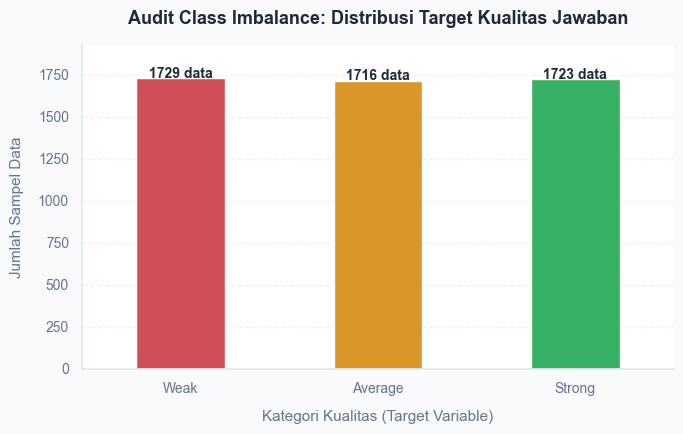

In [136]:
# Hitung jumlah frekuensi riil per kategori target
target_counts = df_eda['quality_label'].value_counts().reindex(['Weak', 'Average', 'Strong'])

# Setup ukuran kanvas grafik (Gunakan subplots, hindari .figure)
fig, ax = plt.subplots(figsize=(7, 4.5))

# Buat bar plot distribusi memakai warna semantik adem yang sudah didefinisikan sebelumnya
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    palette=semantic_palette,
    width=0.45,
    ax=ax
)

# Terapkan fungsi pembantu styling agar rapi dan bersih tanpa garis tepi
apply_dashboard_style(fig, ax)

# Tambahkan label angka presisi di atas setiap bar batang
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} data", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 25), 
                ha='center', va='center', 
                fontsize=10, color='#1F2937', weight='bold')

# Dekorasi teks label grafik
ax.set_title('Audit Class Imbalance: Distribusi Target Kualitas Jawaban', fontsize=13, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Kategori Kualitas (Target Variable)', fontsize=11, labelpad=10)
ax.set_ylabel('Jumlah Sampel Data', fontsize=11, labelpad=10)

# Beri batas ruang atas sumbu Y agar teks angka tidak terpotong
ax.set_ylim(0, target_counts.max() + 200)

plt.tight_layout()
plt.show()

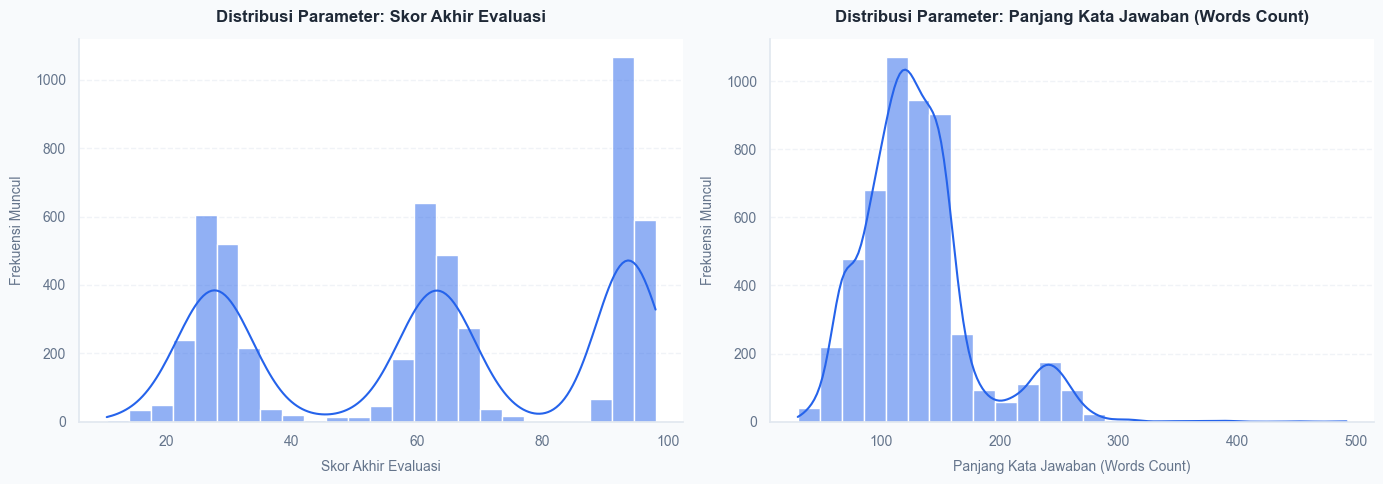

In [137]:
# Pilih fitur numerik yang paling mencerminkan kualitas kompetensi dan kompleksitas teks
numerical_features = ['final_score_0_100', 'answer_length_words']
fitur_labels = ['Skor Akhir Evaluasi', 'Panjang Kata Jawaban (Words Count)']

# Buat 2 grafik bersebelahan (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df_eda,
        x=col,
        kde=True,
        color='#2563EB', # Royal Blue yang hidup dan profesional, bukan abu-abu mati
        ax=axes[i],
        bins=25
    )
    # Jalankan styling dashboard untuk tiap sub-plot
    apply_dashboard_style(fig, axes[i])
    
    axes[i].set_title(f'Distribusi Parameter: {fitur_labels[i]}', fontsize=12, pad=12, weight='bold', color='#1F2937')
    axes[i].set_xlabel(fitur_labels[i], fontsize=10, labelpad=8)
    axes[i].set_ylabel('Frekuensi Muncul', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()

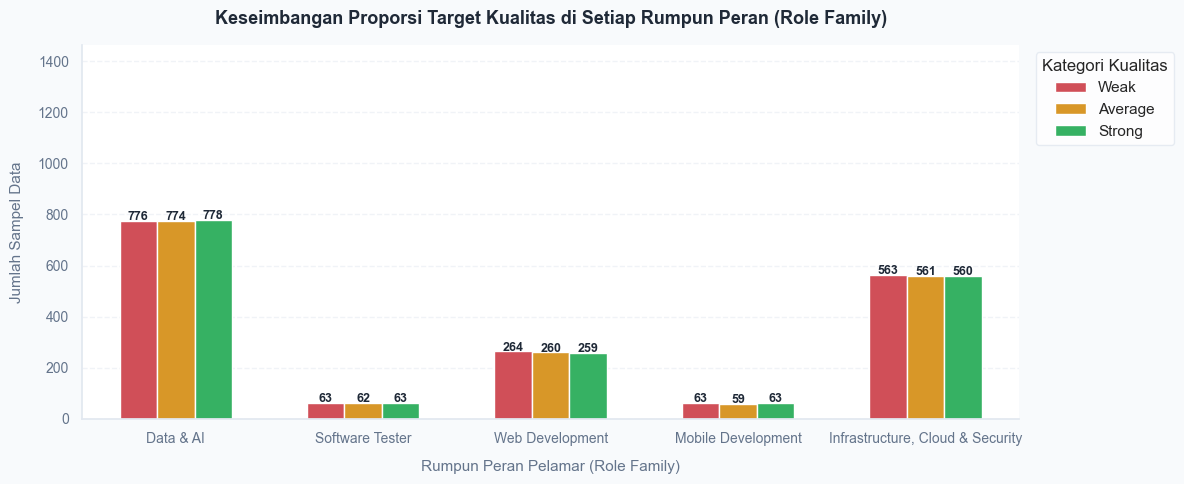

In [138]:
# Setup ukuran kanvas grafik
fig, ax = plt.subplots(figsize=(12, 5))

# Buat Grouped Countplot untuk melihat apakah keseimbangan data merata di setiap rumpun posisi
sns.countplot(
    data=df_eda,
    x='role_family',
    hue='quality_label',
    hue_order=['Weak', 'Average', 'Strong'],
    palette=semantic_palette,
    width=0.6,
    ax=ax
)

# Terapkan fungsi styling
apply_dashboard_style(fig, ax)

# Tambahkan label angka riil di atas masing-masing batang kelompok
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}", 
                    (p.get_x() + p.get_width() / 2., height + 15), 
                    ha='center', va='center', 
                    fontsize=9, color='#1F2937', weight='semibold')

# Dekorasi label teks lengkap
ax.set_title('Keseimbangan Proporsi Target Kualitas di Setiap Rumpun Peran (Role Family)', fontsize=13, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Rumpun Peran Pelamar (Role Family)', fontsize=11, labelpad=10)
ax.set_ylabel('Jumlah Sampel Data', fontsize=11, labelpad=10)

# Berikan ruang ekstra pada sumbu Y atas
ax.set_ylim(0, df_eda['role_family'].value_counts().max() // 2 + 300)

# Pindahkan legenda ke sisi kanan luar grafik agar tidak mengaburkan visualisasi data batang
ax.legend(title='Kategori Kualitas', frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

Dataset memiliki distribusi target (quality_label) yang seimbang sempurna (Perfect Imbalance Check) di setiap rumpun, namun memiliki representasi sampel yang timpang antar rumpun pekerjaan (role_family), di mana rumpun Data & AI mendominasi jalannya pipa data. Dalam kasus ini, `role_family` statusnya adalah fitur input (prediktor), bukan variabel target yang mau ditebak oleh AI. Ketimpangan jumlah data per jurusan ini justru mencerminkan kondisi riil di pasar tenaga kerja IT saat ini (di mana peminat Data & AI serta Cloud/Infra memang jauh lebih membeludak dibanding Software Tester).

### Pertanyaan 1: Berapa rata-rata skor akhir kandidat pada masing-masing tingkat kualitas (*Weak, Average, Strong*) lintas rumpun pekerjaan (*Role Family*) untuk memastikan tidak adanya bias penilaian?

**Mengapa Pertanyaan Ini Penting?**
Analisis ini dibutuhkan untuk mendeteksi adanya **bias penilaian (fairness audit)** dari sistem atau HRD. Kita harus memastikan bahwa standar batas nilai untuk kategori *Strong, Average,* atau *Weak* bersifat konsisten dan adil di semua rumpun pekerjaan, tidak condong atau lebih royal memberikan nilai tinggi pada rumpun peran tertentu saja.

In [116]:
# Agregasi untuk melihat rata-rata skor akhir berdasarkan rumpun peran dan label kualitas
pilar1_q1 = df_eda.groupby(['role_family', 'quality_label'])['final_score_0_100'].agg(['count', 'mean', 'std']).reset_index()

# Urutkan label kualitasnya (Strong -> Average -> Weak)
kategori_urut = {'Strong': 0, 'Average': 1, 'Weak': 2}
pilar1_q1['sort_order'] = pilar1_q1['quality_label'].map(kategori_urut)
pilar1_q1 = pilar1_q1.sort_values(by=['role_family', 'sort_order']).drop(columns=['sort_order'])

print("Tabel Agregasi Skor Akhir Lintas Role Family:")
print(pilar1_q1.to_string(index=False))

Tabel Agregasi Skor Akhir Lintas Role Family:
                     role_family quality_label  count      mean      std
                       Data & AI        Strong    778 93.680206 1.365850
                       Data & AI       Average    774 63.240762 4.068188
                       Data & AI          Weak    776 28.053415 4.420792
Infrastructure, Cloud & Security        Strong    560 93.622679 1.349098
Infrastructure, Cloud & Security       Average    561 63.101693 4.333680
Infrastructure, Cloud & Security          Weak    563 27.605240 4.220186
              Mobile Development        Strong     63 93.426190 0.891983
              Mobile Development       Average     59 60.096610 2.416767
              Mobile Development          Weak     63 25.273810 2.574970
                 Software Tester        Strong     63 93.387302 1.032222
                 Software Tester       Average     62 60.171774 2.217916
                 Software Tester          Weak     63 24.896825 2.571413
     

### Pertanyaan 2: Berapa persentase kandidat yang mengalami ketimpangan penilaian—di mana mereka dinilai memiliki pemahaman teknis yang tinggi namun mendapatkan penilaian kejelasan komunikasi lisan yang rendah—pada keseluruhan sampel wawancara?

**Mengapa Pertanyaan Ini Penting?**
Pertanyaan ini bertujuan untuk memetakan fenomena **"The Silent Geek"**—kandidat yang secara substansi teori atau logika sangat cerdas, namun gagal menyampaikannya dengan terstruktur saat wawancara lisan. Identifikasi persentase dan distribusi lintas role family ini krusial bagi tim produk Road2Work untuk memvalidasi apakah platform perlu menyediakan fitur *Interpersonal Mock-Up Test* tambahan atau modul intervensi khusus pada rumpun pekerjaan tertentu yang paling rentan mengalami kendala ini.

In [117]:
# Sesuai rancangan batasan di awal: pemahaman teknis tinggi (>75) dan komunikasi rendah (<60)
kondisi_timpang = (df_eda['technical_accuracy'] > 75) & (df_eda['communication_clarity'] < 60)

# Hitung jumlah total baris dan jumlah yang memenuhi kondisi ketimpangan
total_sampel = len(df_eda)
jumlah_timpang = kondisi_timpang.sum()
persentase_timpang = (jumlah_timpang / total_sampel) * 100

print(f"Total sampel wawancara       : {total_sampel} baris")
print(f"Jumlah kandidat skor timpang : {jumlah_timpang} orang")
print(f"Persentase kandidat timpang  : {persentase_timpang:.2f}%")

# Ekstraksi tambahan: di rumpun peran mana kasus ketimpangan ini paling sering terjadi?
print("\nDistribusi kasus ketimpangan berdasarkan Rumpun Peran:")
print(df_eda[kondisi_timpang]['role_family'].value_counts())

Total sampel wawancara       : 5168 baris
Jumlah kandidat skor timpang : 81 orang
Persentase kandidat timpang  : 1.57%

Distribusi kasus ketimpangan berdasarkan Rumpun Peran:
role_family
Data & AI                           41
Infrastructure, Cloud & Security    30
Web Development                     10
Name: count, dtype: int64


### Pertanyaan 3: Di antara berbagai komponen kelengkapan respons yang diberikan kandidat (seperti penjelasan konteks, tindakan nyata, ataupun penyertaan bukti angka hasil kerja), elemen mana yang paling menentukan keberhasilan kandidat untuk mencapai kategori kualitas tertinggi ('Strong')?

**Mengapa Pertanyaan Ini Penting?**
Analisis ini bertujuan membongkar rahasia pembeda utama antara jawaban yang berstatus biasa saja (*Average*) dengan jawaban yang dinilai luar biasa (*Strong*). Hasil investigasi ini akan digunakan oleh tim untuk menyusun panduan taktis berbasis data mengenai komponen jawaban apa yang wajib diprioritaskan pelamar saat menjawab pertanyaan *interview* di masa pengembangan mendatang.

In [118]:
# Ambil daftar kolom metrik kelengkapan umum yang sudah dibuat di feature engineering
fitur_kelengkapan = [
    'has_context', 'has_contribution', 'has_tools', 
    'has_impact', 'has_metric', 'has_technical_detail', 'has_self_awareness'
]

# Hitung rata-rata kemunculan komponen berdasarkan tiap tingkatan quality_label
pilar2_q3 = df_eda.groupby('quality_label')[fitur_kelengkapan].mean().reset_index()

# Urutkan (Strong -> Average -> Weak)
pilar2_q3['sort_order'] = pilar2_q3['quality_label'].map({'Strong': 0, 'Average': 1, 'Weak': 2})
pilar2_q3 = pilar2_q3.sort_values('sort_order').drop(columns=['sort_order'])

print("Persentase Kelengkapan Komponen Jawaban Berdasarkan Kategori Kualitas:")
print(pilar2_q3.to_string(index=False))

Persentase Kelengkapan Komponen Jawaban Berdasarkan Kategori Kualitas:
quality_label  has_context  has_contribution  has_tools  has_impact  has_metric  has_technical_detail  has_self_awareness
       Strong     1.000000          1.000000   1.000000    1.000000    1.000000              1.000000            1.000000
      Average     0.994755          0.790210   0.955128    0.151515    0.083916              0.664918            0.997086
         Weak     0.433777          0.178716   0.722961    0.282822    0.252747              0.367843            0.735685


### Pertanyaan 4: Apakah penilaian tinggi dari pewawancara cenderung dipengaruhi oleh panjangnya teks jawaban yang diutarakan kandidat? Pada jumlah kata ke berapa rata-rata skor kompetensi teknis kandidat mulai mengalami titik jenuh (plateau)?

**Mengapa Pertanyaan Ini Penting?**
Investigasi ini dilakukan untuk memvalidasi ada tidaknya **Verbosity Bias** (kecenderungan menilai tinggi jawaban hanya karena kandidat berbicara panjang lebar, bukan karena isinya berbobot). Dengan menemukan titik jenuh (*plateau*), platform bisa membatasi durasi atau memberikan peringatan *real-time* kepada user agar tidak memberikan jawaban yang bertele-tele namun minim substansi teknis.

In [119]:
# Buat binning/pengelompokan panjang kata per 50 kata agar trennya lebih mudah dibaca
df_eda['word_count_bin'] = pd.cut(df_eda['answer_length_words'], bins=range(0, 1000, 50))

# Hitung rata-rata skor technical_accuracy untuk setiap kelompok panjang kata
pilar2_q4 = df_eda.groupby('word_count_bin', observed=False)['technical_accuracy'].agg(['count', 'mean']).reset_index()

print("Analisis Titik Jenuh: Hubungan Panjang Kata dengan Rata-rata Skor Teknis:")
print(pilar2_q4.head(15).to_string(index=False))

Analisis Titik Jenuh: Hubungan Panjang Kata dengan Rata-rata Skor Teknis:
word_count_bin  count      mean
       (0, 50]     45 24.444444
     (50, 100]   1242 47.822866
    (100, 150]   2653 68.728609
    (150, 200]    757 80.188904
    (200, 250]    327 43.691131
    (250, 300]    128 42.296875
    (300, 350]      8 86.125000
    (350, 400]      6 87.333333
    (400, 450]      0       NaN
    (450, 500]      2 95.000000
    (500, 550]      0       NaN
    (550, 600]      0       NaN
    (600, 650]      0       NaN
    (650, 700]      0       NaN
    (700, 750]      0       NaN


### Pertanyaan 5: Berapa proporsi distribusi kandidat yang masih tertahan di tingkat kedalaman bukti paling bawah (hanya sekadar klaim kemampuan atau menyebutkan keahlian tanpa konteks) berdasarkan masing-masing rumpun peran?

**Mengapa Pertanyaan Ini Penting?**
Analisis ini digunakan untuk mendeteksi rumpun peran (*Role Family*) mana yang paling kritis atau paling banyak diisi oleh kandidat "omong doang" (kandidat yang hanya berada di *Evidence Level* 1 atau 2). Hasil ini penting agar platform Road2Work bisa menargetkan distribusi modul remedial pembuatan portofolio secara tepat sasaran di pengembangan berikutnya.

In [120]:
# Level bawah didefinisikan sebagai Evidence Level 1 (Claim) & Level 2 (Skill)
df_level_bawah = df_eda[df_eda['evidence_level'].isin([1, 2])]

# Hitung distribusi per rumpun peran
pilar3_q5 = df_level_bawah['role_family'].value_counts().reset_index()
pilar3_q5.columns = ['role_family', 'jumlah_kandidat_level_bawah']

# Hitung juga persentasenya terhadap total kandidat di masing-masing rumpun tersebut
total_per_rumpun = df_eda['role_family'].value_counts().reset_index()
total_per_rumpun.columns = ['role_family', 'total_kandidat']

# Gabungkan untuk melihat proporsi riil
pilar3_q5 = pd.merge(pilar3_q5, total_per_rumpun, on='role_family')
pilar3_q5['persentase_tertahan'] = (pilar3_q5['jumlah_kandidat_level_bawah'] / pilar3_q5['total_kandidat']) * 100

print("Distribusi Kandidat yang Tertahan di Evidence Level Bawah (Level 1 & 2):")
print(pilar3_q5.to_string(index=False))

Distribusi Kandidat yang Tertahan di Evidence Level Bawah (Level 1 & 2):
                     role_family  jumlah_kandidat_level_bawah  total_kandidat  persentase_tertahan
                       Data & AI                          776            2328            33.333333
Infrastructure, Cloud & Security                          563            1684            33.432304
                 Web Development                          264             783            33.716475
              Mobile Development                           63             185            34.054054
                 Software Tester                           63             188            33.510638


### Pertanyaan 6: Lima jenis catatan kelemahan atau kendala kompetensi apa saja yang memiliki frekuensi kemunculan tertinggi hingga membuat kandidat dinilai paling sering membutuhkan pertanyaan klarifikasi lanjutan saat sesi wawancara?

**Mengapa Pertanyaan Ini Penting?**
Kita ingin mengetahui *common mistakes* atau musuh terbesar pelamar kerja saat *interview* yang memicu sistem mengaktifkan status `need_clarification = True`. Informasi tiga kelemahan teratas ini akan menjadi fondasi utama dalam menyusun algoritma *Clarifying Question Engine* agar bisa menembak kelemahan user secara otomatis.

In [121]:
# Filter data hanya untuk kandidat yang butuh klarifikasi lanjutan
df_klarifikasi = df_eda[df_eda['need_clarification'] == True]

# Pecah dulu teksnya, karena satu baris bisa berisi banyak tag yang dipisah titik koma (;)
all_tags = []
df_klarifikasi['weakness_tags'].dropna().apply(lambda x: all_tags.extend(str(x).split(';')))

# Ubah menjadi Series agar bisa dihitung frekuensi kemunculan top 3 nya
pilar3_q6 = pd.Series(all_tags).value_counts().head(5).reset_index()
pilar3_q6.columns = ['catatan_kelemahan_tags', 'frekuensi_kemunculan']

print("Top 5 Catatan Kelemahan Utama yang Memicu Kebutuhan Klarifikasi:")
print(pilar3_q6.to_string(index=False))

Top 5 Catatan Kelemahan Utama yang Memicu Kebutuhan Klarifikasi:
   catatan_kelemahan_tags  frekuensi_kemunculan
measurable_result_missing                  2864
           impact_missing                  2696
   star_structure_missing                  2077
     contribution_unclear                  1780
 technical_detail_missing                  1668


### Pertanyaan 7: Bagaimana korelasi antara tingkat relevansi jawaban kandidat terhadap peran yang dituju dengan pencapaian tingkat kedalaman bukti konkret yang mereka berikan?

**Mengapa Pertanyaan Ini Penting?**
Analisis korelasi ini bertujuan menguji kebenaran hipotesis rekrutmen: *"Apakah kandidat yang bicaranya sangat nyambung dengan posisi lamaran (role_relevance tinggi) otomatis mampu memberikan bukti kerja yang mendalam (evidence_level tinggi)?"*. Jika korelasinya rendah, berarti banyak pelamar yang sekadar pintar mencocokkan kata kunci (*keyword matching*) tanpa benar-benar punya pengalaman nyata.

In [122]:
# Menghitung korelasi Spearman antara skor relevansi peran dengan tingkatan level bukti
# Pakai Spearman karena evidence_level sifatnya data ordinal/tingkatan (1 sampai 5)
korelasi_spearman = df_eda['role_relevance'].corr(df_eda['evidence_level'], method='spearman')

print(f"Koefisien Korelasi Spearman antara Relevansi Peran dan Level Bukti: {korelasi_spearman:.4f}")

# Tambahan analisis: tampilkan rata-rata nilai relevansi untuk setiap tingkatan evidence_level
print("\nRata-rata Skor Relevansi Peran pada Tiap Tingkat Kedalaman Bukti (Evidence Level 1-5):")
print(df_eda.groupby('evidence_level')['role_relevance'].mean().reset_index().to_string(index=False))

Koefisien Korelasi Spearman antara Relevansi Peran dan Level Bukti: 0.9650

Rata-rata Skor Relevansi Peran pada Tiap Tingkat Kedalaman Bukti (Evidence Level 1-5):
 evidence_level  role_relevance
              1       36.596314
              2       43.617021
              3       69.315224
              4       75.612245
              5       95.079883


## Visualization & Explanatory Analysis

### Visualisasi Pilar 1: Analisis Keadilan & Standarisasi Penilaian HRD

#### Grafik 1: Sebaran Skor Akhir Lintas Rumpun Peran Berdasarkan Label Kualitas (SMART Q1)

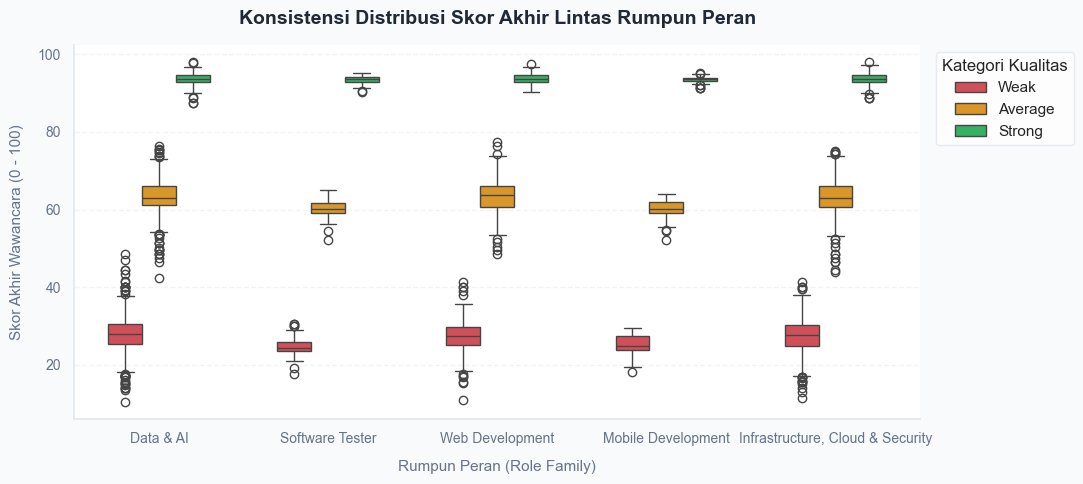

In [124]:
# Setup ukuran kanvas grafik
fig, ax = plt.subplots(figsize=(11, 5))

# Buat Grouped Boxplot
sns.boxplot(
    data=df_eda,
    x='role_family',
    y='final_score_0_100',
    hue='quality_label',
    hue_order=['Weak', 'Average', 'Strong'],
    palette=semantic_palette,
    width=0.6,
    ax=ax
)

# Fungsi styling 
apply_dashboard_style(fig, ax)

# Dekorasi teks label
ax.set_title('Konsistensi Distribusi Skor Akhir Lintas Rumpun Peran', fontsize=14, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Rumpun Peran (Role Family)', fontsize=11, labelpad=10)
ax.set_ylabel('Skor Akhir Wawancara (0 - 100)', fontsize=11, labelpad=10)

ax.legend(
    title='Kategori Kualitas', 
    frameon=True, 
    facecolor='#FFFFFF', 
    edgecolor='#E2E8F0',
    bbox_to_anchor=(1.01, 1), 
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### Grafik 2: Distribusi Kasus Ketimpangan Nilai Wawancara (SMART Q2)
*Kandidat dengan kriteria Technical Accuracy > 75 (Tinggi) namun Communication Clarity < 60 (Rendah).*

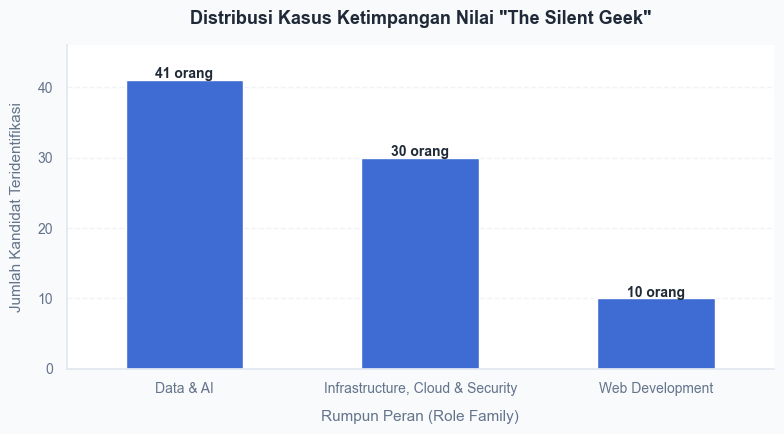

In [125]:
# Filter data kandidat yang masuk kriteria ketimpangan nilai
df_timpang = df_eda[(df_eda['technical_accuracy'] > 75) & (df_eda['communication_clarity'] < 60)]

# Hitung jumlah kasus per rumpun peran
kasus_per_role = df_timpang['role_family'].value_counts().reset_index()
kasus_per_role.columns = ['role_family', 'jumlah_kasus']

# Setup kanvas grafik
fig, ax = plt.subplots(figsize=(8, 4.5))

# FIX: Mengubah color ke Royal/Deep Blue (#2563EB) agar grafiknya "hidup" dan profesional
sns.barplot(
    data=kasus_per_role,
    x='role_family',
    y='jumlah_kasus',
    color='#2563EB', # Biru solid yang tegas dan gak berkesan "disabled"
    width=0.5,
    ax=ax
)

# Terapkan fungsi styling agar clean dan minimalis
apply_dashboard_style(fig, ax)

# Beri nilai teks angka di atas setiap bar batang agar informatif
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} orang", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.8), 
                ha='center', va='center', 
                fontsize=10, color='#1F2937', weight='bold') # Teks angka kita bikin gelap (#1F2937) biar kontras

# Beri dekorasi teks label
ax.set_title('Distribusi Kasus Ketimpangan Nilai "The Silent Geek"', fontsize=13, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Rumpun Peran (Role Family)', fontsize=11, labelpad=10)
ax.set_ylabel('Jumlah Kandidat Teridentifikasi', fontsize=11, labelpad=10)

# Berikan kelonggaran sedikit di sumbu Y atas untuk teks anotasi angka
ax.set_ylim(0, kasus_per_role['jumlah_kasus'].max() + 5)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- xxx
- xxx

### Visualisasi Pilar 2: Anatomi Jawaban Sukses & Pola Struktur Metrik

#### Grafik 3: Heatmap Tingkat Kelengkapan Komponen Jawaban Lintas Kategori Kualitas (SMART Q3)

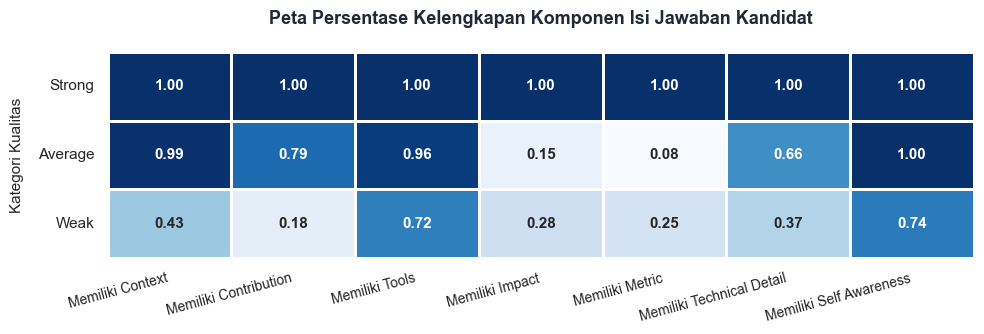

In [126]:
# Hitung data rata-rata agregasi 
fitur_kelengkapan = ['has_context', 'has_contribution', 'has_tools', 'has_impact', 'has_metric', 'has_technical_detail', 'has_self_awareness']
pilar2_q3_raw = df_eda.groupby('quality_label')[fitur_kelengkapan].mean()

# Urutkan indeks baris (Strong -> Average -> Weak)
pilar2_q3_raw = pilar2_q3_raw.reindex(['Strong', 'Average', 'Weak'])

# Setup kanvas grafik
fig, ax = plt.subplots(figsize=(10, 3.5))

sns.heatmap(
    pilar2_q3_raw, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    linewidths=1, 
    cbar=False, 
    ax=ax,
    annot_kws={"size": 11, "weight": "bold"}
)

# Sesuaikan label sumbu X
label_x_manusiawi = [col.replace('has_', 'Memiliki ').replace('_', ' ').title() for col in fitur_kelengkapan]
ax.set_xticklabels(label_x_manusiawi, rotation=15, ha='right', fontsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=11)

ax.set_title('Peta Persentase Kelengkapan Komponen Isi Jawaban Kandidat', fontsize=13, pad=20, weight='bold', color='#1F2937')
ax.set_ylabel('Kategori Kualitas', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

#### Grafik 4: Tren Skor Teknis Berdasarkan Kelompok Panjang Kata Jawaban (SMART Q4)

C:\Users\nurul\AppData\Local\Temp\ipykernel_2164\285431786.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pilar2_q4_clean['word_bin_str'], rotation=30, ha='right')


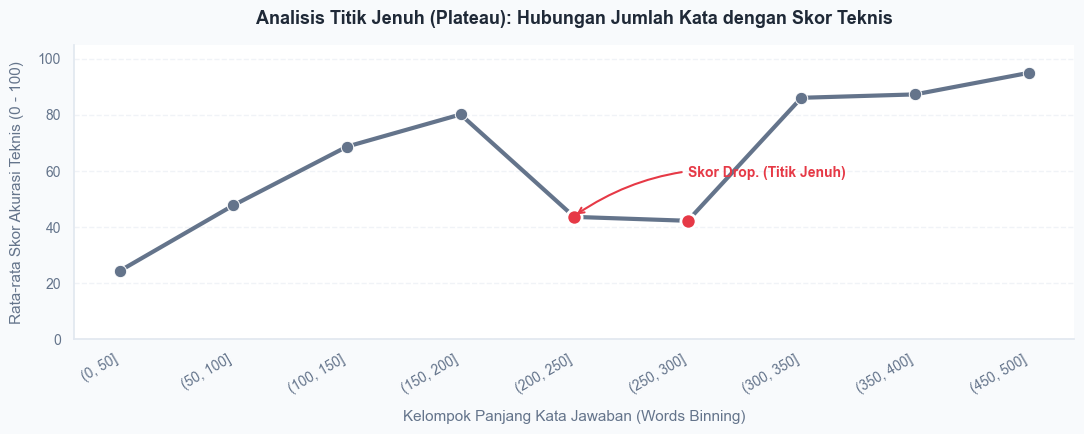

In [127]:
# Ambil data agregasi binning kelompok kata
pilar2_q4_clean = pilar2_q4.dropna(subset=['mean']).copy()

# Konversi interval kategori binning menjadi string koordinat titik tengah atau teks statis agar bisa di-plot sebagai Line Plot
pilar2_q4_clean['word_bin_str'] = pilar2_q4_clean['word_count_bin'].astype(str)

# Setup ukuran kanvas grafik
fig, ax = plt.subplots(figsize=(11, 4.5))

# 1. Gambar garis tren utamanya dengan warna Slate Netral
sns.lineplot(
    data=pilar2_q4_clean,
    x='word_bin_str',
    y='mean',
    linewidth=3,
    color='#64748B', # Warna netral abu-abu dashboard
    ax=ax,
    zorder=1
)

# 2. Plot semua titik (markers) dengan warna abu-abu dulu
sns.scatterplot(
    data=pilar2_q4_clean,
    x='word_bin_str',
    y='mean',
    color='#64748B',
    s=80,
    ax=ax,
    zorder=2
)

# 3. AKSEN BRAND: Warnai MERAH hanya pada titik jenuh (rentang kata 200-250 dan 250-300)
df_drop = pilar2_q4_clean[pilar2_q4_clean['word_bin_str'].isin(['(200, 250]', '(250, 300]'])]
sns.scatterplot(
    data=df_drop,
    x='word_bin_str',
    y='mean',
    color='#E63946',
    s=120,
    edgecolor='#FFFFFF',
    linewidth=2,
    ax=ax,
    zorder=3
)

# Terapkan fungsi styling
apply_dashboard_style(fig, ax)
ax.set_xticklabels(pilar2_q4_clean['word_bin_str'], rotation=30, ha='right')

# Beri dekorasi teks label pelengkap
ax.set_title('Analisis Titik Jenuh (Plateau): Hubungan Jumlah Kata dengan Skor Teknis', fontsize=13, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Kelompok Panjang Kata Jawaban (Words Binning)', fontsize=11, labelpad=10)
ax.set_ylabel('Rata-rata Skor Akurasi Teknis (0 - 100)', fontsize=11, labelpad=10)
ax.set_ylim(0, 105)

# Tambahkan anotasi teks di titik merah biar makin infografis
ax.annotate('Skor Drop. (Titik Jenuh)', xy=('(200, 250]', 44), xytext=('(250, 300]', 58),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color='#E63946', lw=1.5),
            fontsize=10, color='#E63946', weight='bold')

plt.tight_layout()
plt.show()

### Visualisasi Pilar 3: Analisis Kesenjangan Kompetensi Pelamar Kerja

#### Grafik 5: Persentase Kandidat yang Tertahan di Evidence Level Rendah (SMART Q5)

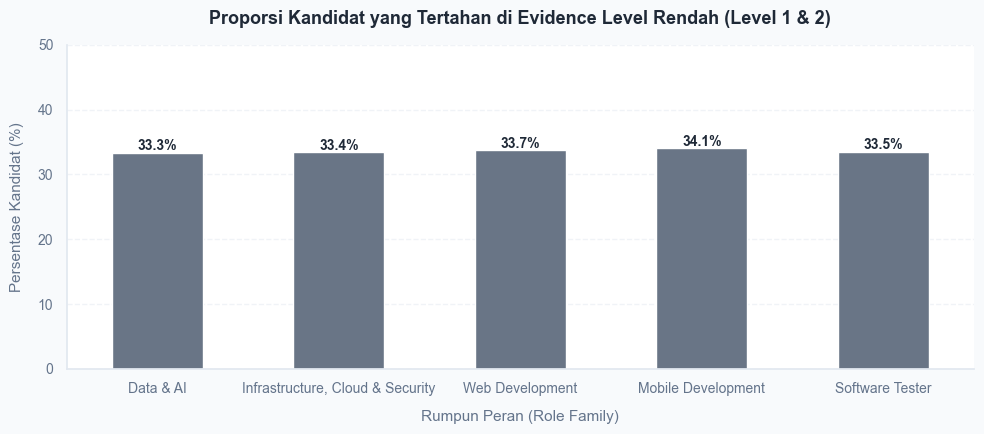

In [128]:
# Setup ukuran kanvas grafik
fig, ax = plt.subplots(figsize=(10, 4.5))

# Buat bar plot dengan warna Slate netral yang elegan
sns.barplot(
    data=pilar3_q5,
    x='role_family',
    y='persentase_tertahan',
    color='#64748B', # Slate Blue netral
    width=0.5,
    ax=ax
)

# Terapkan fungsi styling
apply_dashboard_style(fig, ax)

# Tambahkan label angka persentase tepat di atas bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 1), 
                ha='center', va='center', 
                fontsize=10, color='#1F2937', weight='bold')

# Dekorasi teks
ax.set_title('Proporsi Kandidat yang Tertahan di Evidence Level Rendah (Level 1 & 2)', fontsize=13, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Rumpun Peran (Role Family)', fontsize=11, labelpad=10)
ax.set_ylabel('Persentase Kandidat (%)', fontsize=11, labelpad=10)
ax.set_ylim(0, 50)

plt.tight_layout()
plt.show()

#### Grafik 6: Top 5 Catatan Kelemahan Utama Pemicu Pertanyaan Klarifikasi (SMART Q6)

C:\Users\nurul\AppData\Local\Temp\ipykernel_2164\4268710148.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(label_y_manusiawi, fontsize=10, weight='medium')


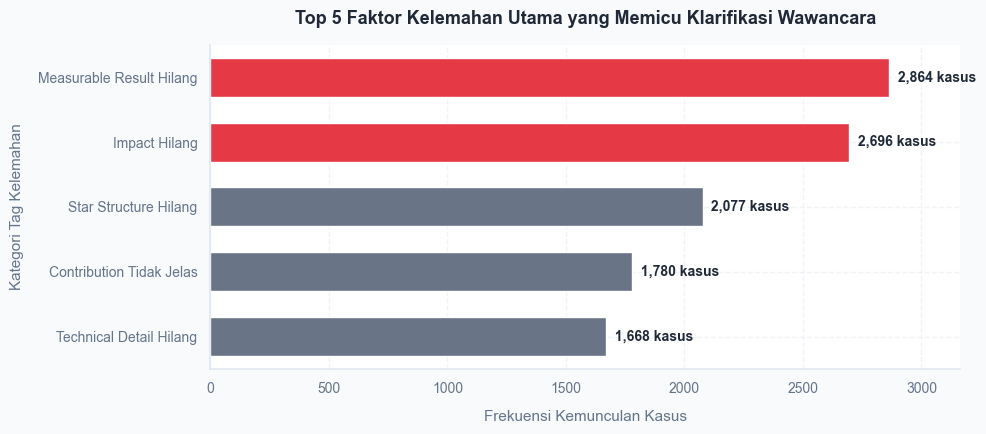

In [129]:
# Setup ukuran kanvas grafik
fig, ax = plt.subplots(figsize=(10, 4.5))

# Buat Horizontal Bar Plot biar pembacaan nama tag kelemahan yang panjang jadi lebih mudah
sns.barplot(
    data=pilar3_q6,
    x='frekuensi_kemunculan',
    y='catatan_kelemahan_tags',
    color='#64748B', # Slate Blue netral
    width=0.6,
    ax=ax
)

# Terapkan fungsi styling
apply_dashboard_style(fig, ax)
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#E2E8F0') # Grid kita balik ke sumbu X karena grafiknya horizontal

# Ubah nama label Y agar lebih manusiawi dan tidak terlalu berbau kode/teknis
label_y_manusiawi = [tag.replace('_missing', ' Hilang').replace('_unclear', ' Tidak Jelas').replace('_', ' ').title() for tag in pilar3_q6['catatan_kelemahan_tags']]
ax.set_yticklabels(label_y_manusiawi, fontsize=10, weight='medium')

# AKSEN MERAH BRAND: Kita beri warna merah khusus untuk Bar peringkat 1 & 2 (Dua musuh terbesar kandidat)
ax.patches[0].set_facecolor('#E63946')
ax.patches[1].set_facecolor('#E63946')

# Tambahkan nilai angka frekuensi di ujung kanan setiap bar
for p in ax.patches:
    ax.annotate(f" {int(p.get_width()):,} kasus", 
                (p.get_width() + 20, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                fontsize=10, color='#1F2937', weight='bold')

# Dekorasi teks
ax.set_title('Top 5 Faktor Kelemahan Utama yang Memicu Klarifikasi Wawancara', fontsize=13, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Frekuensi Kemunculan Kasus', fontsize=11, labelpad=10)
ax.set_ylabel('Kategori Tag Kelemahan', fontsize=11, labelpad=10)
ax.set_xlim(0, pilar3_q6['frekuensi_kemunculan'].max() + 300)

plt.tight_layout()
plt.show()

#### Grafik 7: Analisis Hubungan Linear antara Skor Relevansi Peran dengan Kedalaman Bukti (SMART Q7)

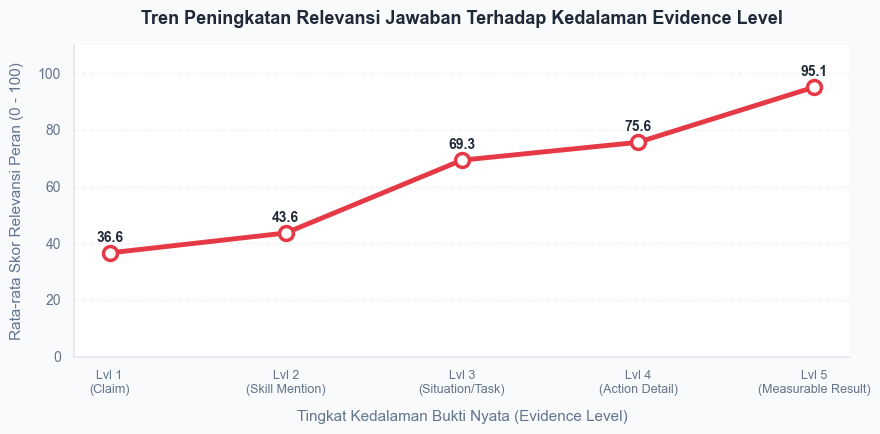

In [130]:
# Hitung nilai rata-rata relevansi per level bukti
trend_data = df_eda.groupby('evidence_level')['role_relevance'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))

# 1. Gambar GARISNYA DULU (Polosan tanpa marker biar gak keputus di tengah)
sns.lineplot(
    data=trend_data,
    x='evidence_level',
    y='role_relevance',
    linewidth=3.5,
    color='#E63946', # Merah brand tegas nyambung terus
    ax=ax,
    zorder=1
)

# 2. Tumpuk MARKER PUTIHNYA pakai scatter plot di atas garis
sns.scatterplot(
    data=trend_data,
    x='evidence_level',
    y='role_relevance',
    s=100,               # Ukuran bulatan
    color='#FFFFFF',     # Isian titik putih tengah
    edgecolor='#E63946', # Bingkai luar merah brand
    linewidth=2.5,       # Tebal bingkai luar
    ax=ax,
    zorder=2             # Memastikan titik berada di atas garis
)

# Terapkan fungsi styling
apply_dashboard_style(fig, ax)

# Ubah label sumbu X dari angka ordinal murni menjadi penjelasan level bukti kontekstual
ax.set_xticks(trend_data['evidence_level'])
ax.set_xticklabels(['Lvl 1\n(Claim)', 'Lvl 2\n(Skill Mention)', 'Lvl 3\n(Situation/Task)', 'Lvl 4\n(Action Detail)', 'Lvl 5\n(Measurable Result)'], fontsize=9)

# Tambahkan teks nilai rata-rata di atas titik marker (naikin sedikit +4 biar gak numpuk)
for index, row in trend_data.iterrows():
    ax.text(row['evidence_level'], row['role_relevance'] + 4, f"{row['role_relevance']:.1f}", 
            color='#1F2937', ha="center", weight='bold', fontsize=10)

# Dekorasi teks
ax.set_title('Tren Peningkatan Relevansi Jawaban Terhadap Kedalaman Evidence Level', fontsize=13, pad=15, weight='bold', color='#1F2937')
ax.set_xlabel('Tingkat Kedalaman Bukti Nyata (Evidence Level)', fontsize=11, labelpad=10)
ax.set_ylabel('Rata-rata Skor Relevansi Peran (0 - 100)', fontsize=11, labelpad=10)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** xxx
- **Conclusion pertanyaan 2:** xxx
- ...

**Rekomendasi Action Item:**
- xxx
- xxx

## Data Splitting (Train, Validation, Test Split)
Pada tahap ini, dataset yang telah bersih dan kaya fitur akan dibagi menjadi tiga bagian terpisah: Train Set (70%) untuk melatih model, Validation Set (15%) untuk tuning dan validasi internal, serta Test Set (15%) sebagai ujian akhir untuk mengevaluasi performa model Machine Learning secara objektif.

In [140]:
# 1. Tentukan fitur (X) dan target (y) 
df_eda['stratify_col'] = df_eda['role_family'].astype(str) + "_" + df_eda['quality_label'].astype(str)

# Split pertama: Pisahkan Train (70%) dan Sisa/Temp (30%)
train_df, temp_df = train_test_split(
    df_eda, 
    test_size=0.30, 
    random_state=42, 
    stratify=df_eda['stratify_col']
)

# Split kedua: Bagi Sisa/Temp (30%) tadi menjadi Validation (15%) dan Test (15%) seimbang rata
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['stratify_col']
)

# Drop kembali kolom pembantu stratify agar data tetap steril
for data_split in [train_df, val_df, test_df]:
    data_split.drop(columns=['stratify_col'], inplace=True, errors='ignore')

# 2. Definisikan path folder tujuan di kasta tertinggi (03_processed)
processed_dir = "../data/03_processed/"
os.makedirs(processed_dir, exist_ok=True)

# Ekspor ketiga pecahan data menjadi file CSV terpisah
train_df.to_csv(os.path.join(processed_dir, "train_df.csv"), index=False)
val_df.to_csv(os.path.join(processed_dir, "val_df.csv"), index=False)
test_df.to_csv(os.path.join(processed_dir, "test_df.csv"), index=False)

# 3. Print laporan hasil pemotongan data untuk validasi akhir
print("=== LAPORAN DISTRIBUSI DATA SPLITTING ===")
print(f"Total Data Awal : {len(df_eda)} baris")
print(f"Train Set (80%) : {len(train_df)} baris ➔ Disimpan di 03_processed/train_df.csv")
print(f"Val Set (10%)   : {len(val_df)} baris ➔ Disimpan di 03_processed/val_df.csv")
print(f"Test Set (10%)  : {len(test_df)} baris ➔ Disimpan di 03_processed/test_df.csv")

=== LAPORAN DISTRIBUSI DATA SPLITTING ===
Total Data Awal : 5168 baris
Train Set (80%) : 3617 baris ➔ Disimpan di 03_processed/train_df.csv
Val Set (10%)   : 775 baris ➔ Disimpan di 03_processed/val_df.csv
Test Set (10%)  : 776 baris ➔ Disimpan di 03_processed/test_df.csv
